Shape: (976, 11)

Dtypes:
Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run           int64
No_of_Owners         object
Seating_Capacity      int64
Fuel_Type            object
Transmission         object
Transmission_Type    object
Price                 int64
dtype: object

Missing values:
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64
Unique values in categorical columns:
  Make: ['Chevrolet', 'Datsun', 'Ford', 'Honda', 'Hyundai', 'Jeep', 'Kia', 'MG Motors', 'Mahindra', 'Maruti Suzuki', 'Nissan', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen']
  Color: ['beige', 'black', 'blue', 'bronze', 'brown', 'golden', 'green', 'grey', 'maroon', 'orange', 'purple', 'red', 'silver', 'white', 'yellow']
  Bo

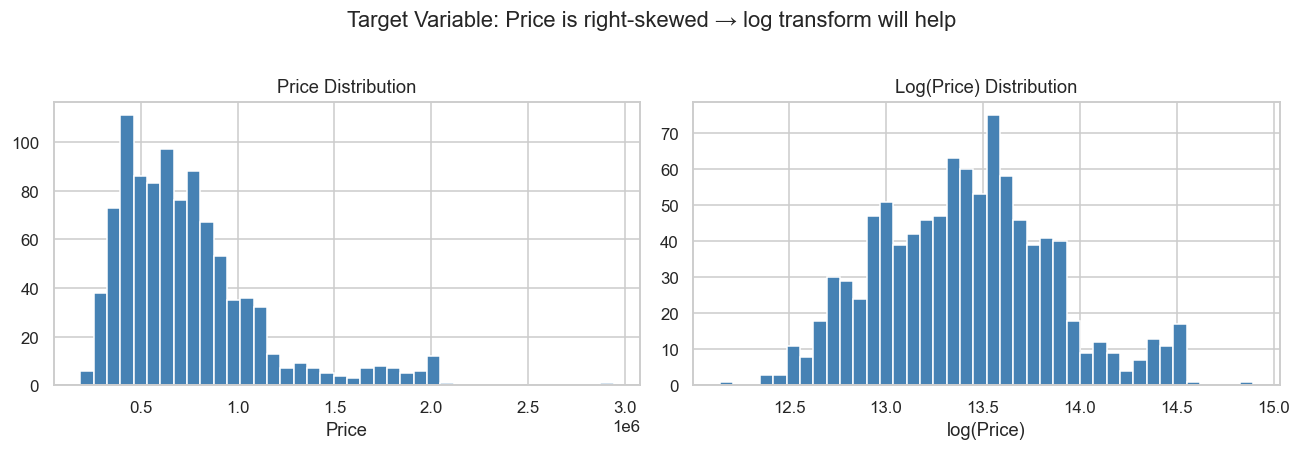

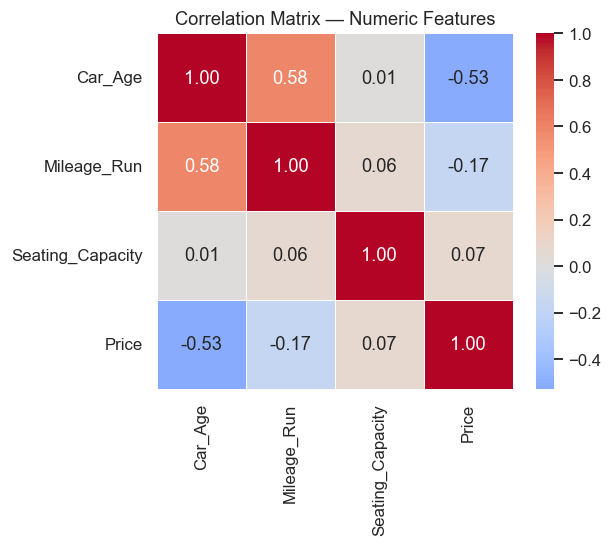

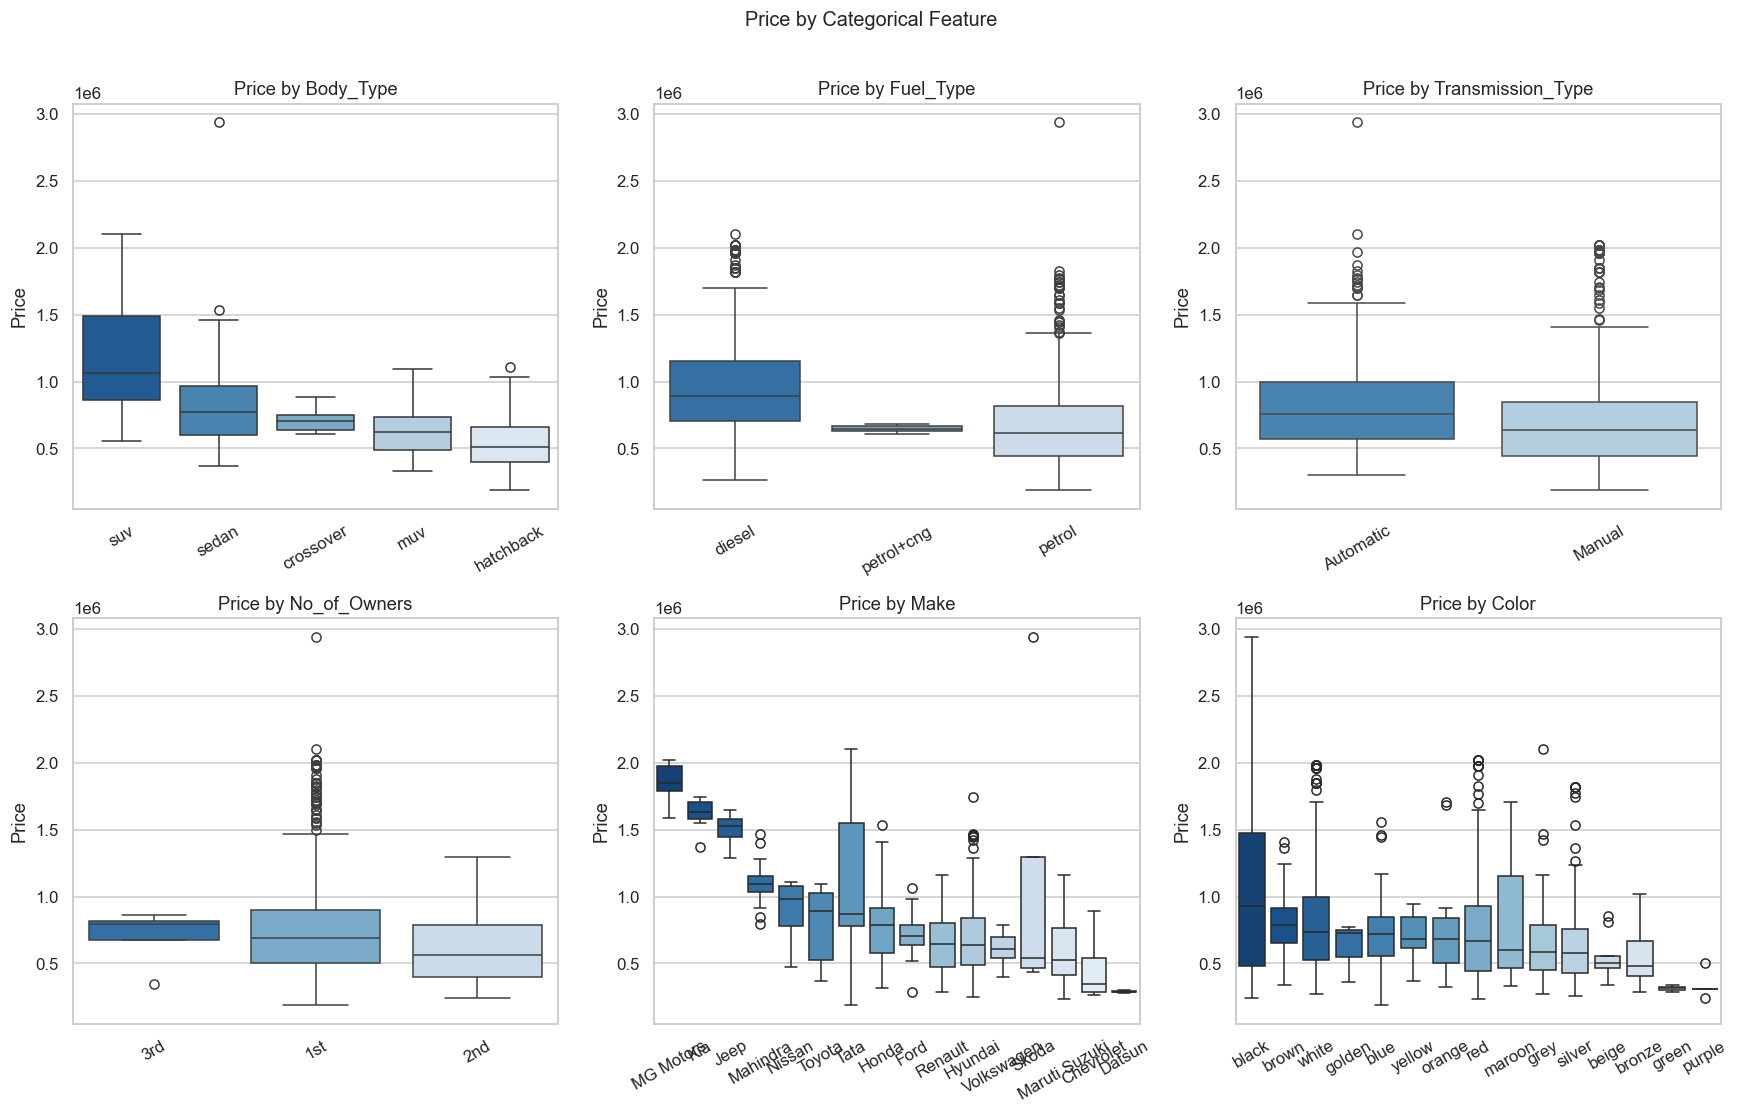

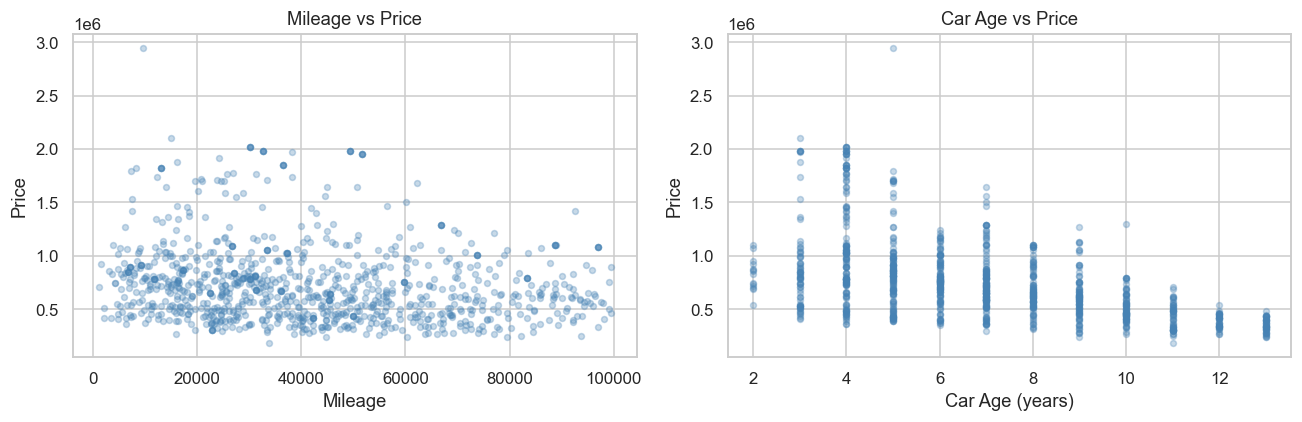

Unmapped owners: 0
Final shape: (976, 41)
Train: 780 rows | Test: 196 rows


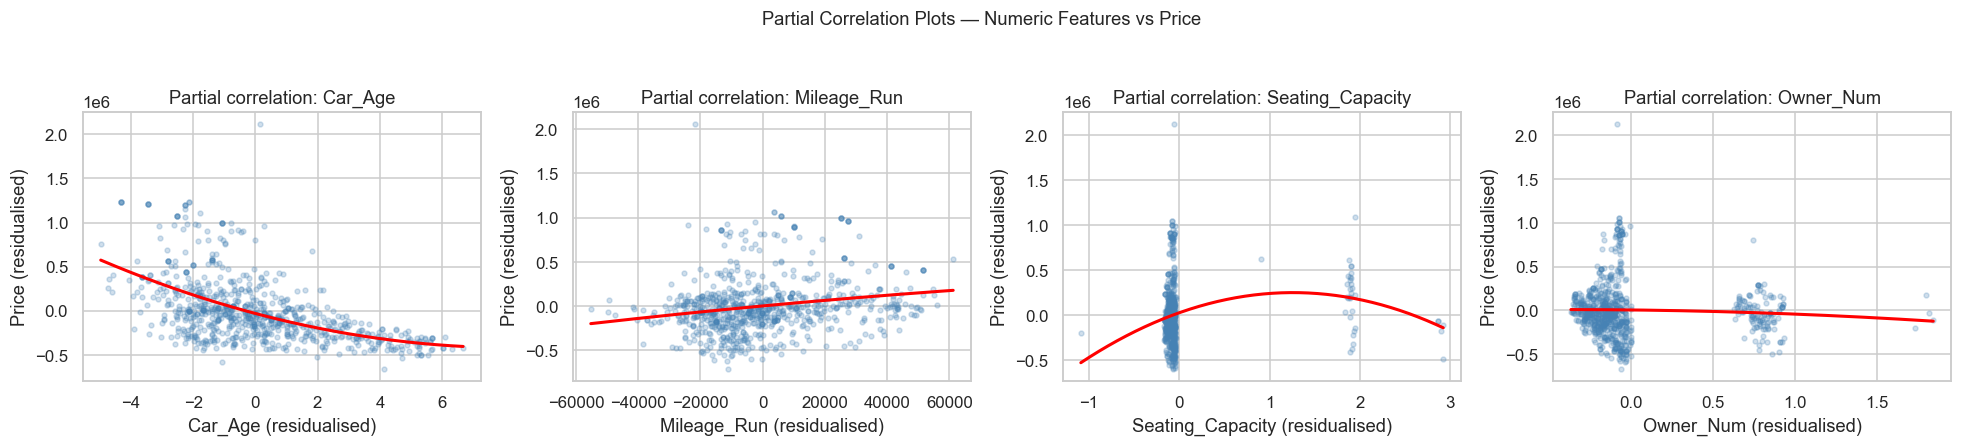

Complex feature set shape: (780, 43)
New features added: ['log_Mileage', 'Car_Age_sq', 'Age_x_Mileage', 'Owner_x_Mileage']


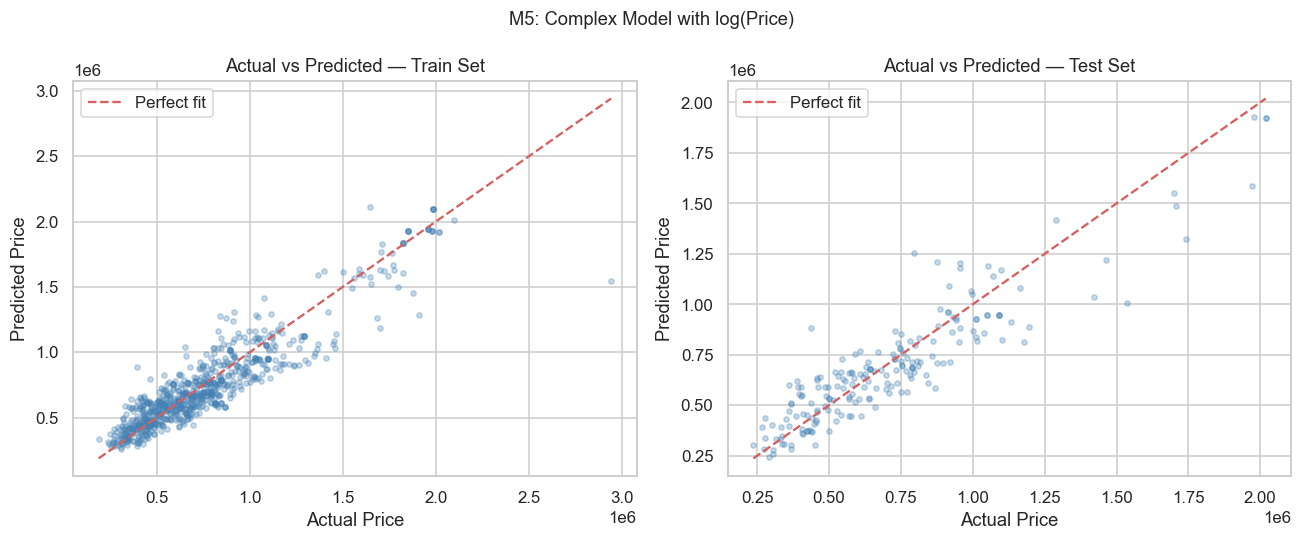

Best alpha: 0.0037
Train RMSE: 148,383
Test RMSE:  143,981
Train R²:   0.821
Test R²:    0.790
38 features selected out of 43


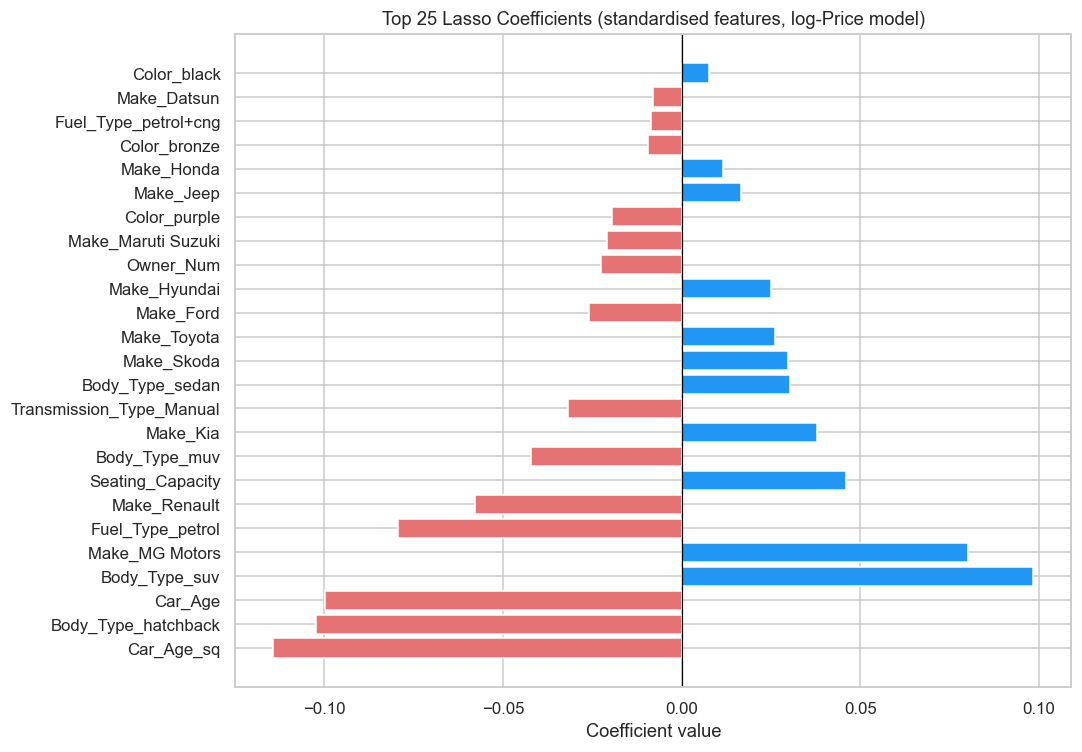

HEDONIC PRICING — SUMMARY & CONCLUSIONS

WHAT DRIVES USED CAR PRICES?
-------------------------------
The Lasso model selected 38 out of 43 features,
confirming that most variables carry genuine signal. The top
price drivers are:
  1. Make  — brand/manufacturer (largest effect)
  2. Fuel type  — electric/diesel vs petrol
  3. Car age + mileage  — key depreciation drivers (non-linear)
  4. Owner history  — 1st-owner cars command a premium
  5. Body type  — SUVs and crossovers vs hatchbacks

OVERFITTING vs UNDERFITTING
-------------------------------
M1 (numeric-only) UNDERFITS: test RMSE = 284,941
  → Missing brand and category info leaves a lot unexplained.

M5/M6 (complex + log price) perform best: test RMSE = 143,981
  → 49.5% improvement over the simplest model.

Train vs Test RMSE stayed close across all models, meaning
NO severe overfitting occurred. The dataset (~976 rows) is
large enough relative to feature count to generalise well.

KEY MODELLING LESSONS
-----------------------

In [3]:
#in collaboration with Jaitha Jasti
#ChatGPT was used as an aid

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
df = pd.read_csv('cars_hw.csv', index_col=0)
df.head()

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

print('Unique values in categorical columns:')
for col in ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']:
    print(f'  {col}: {sorted(df[col].unique())}')

    # No missing values. Strip whitespace just in case.
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

# Compute car age — more interpretable than raw year
df['Car_Age'] = 2024 - df['Make_Year']

print('Dataset is clean — no nulls, no duplicates.')
df.describe()

# --- Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')

axes[1].hist(np.log(df['Price']), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Log(Price) Distribution')
axes[1].set_xlabel('log(Price)')

plt.suptitle('Target Variable: Price is right-skewed → log transform will help', y=1.02)
plt.tight_layout()
plt.show()

# --- Numeric correlations with Price ---
num_cols = ['Car_Age', 'Mileage_Run', 'Seating_Capacity', 'Price']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

# --- Categorical features vs Price ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cats = ['Body_Type', 'Fuel_Type', 'Transmission_Type', 'No_of_Owners', 'Make', 'Color']
for ax, col in zip(axes.flat, cats):
    order = df.groupby(col)['Price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Price', order=order, ax=ax, palette='Blues_r')
    ax.set_title(f'Price by {col}')
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('')
plt.suptitle('Price by Categorical Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Mileage vs Price scatter ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['Mileage_Run'], df['Price'], alpha=0.3, s=15, color='steelblue')
axes[0].set_xlabel('Mileage'); axes[0].set_ylabel('Price'); axes[0].set_title('Mileage vs Price')

axes[1].scatter(df['Car_Age'], df['Price'], alpha=0.3, s=15, color='steelblue')
axes[1].set_xlabel('Car Age (years)'); axes[1].set_ylabel('Price'); axes[1].set_title('Car Age vs Price')
plt.tight_layout()
plt.show()

#EDA Takeaways:
#Price is right-skewed → log transform is appropriate
#Car age and mileage are negatively correlated with price
#Fuel type (diesel/electric/hybrid) and body type show meaningful price differences
#Owner history matters: 1st-owner cars command a premium
#Some brands (luxury) clearly command higher prices

# 2

df_model = df.copy()

# --- Ordinal encode No_of_Owners (natural order) ---
owner_map = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}
df_model['Owner_Num'] = df_model['No_of_Owners'].map(owner_map)
print('Unmapped owners:', df_model['Owner_Num'].isnull().sum())

# --- One-hot encode remaining categoricals ---
cat_cols = ['Body_Type', 'Fuel_Type', 'Transmission_Type', 'Color', 'Make']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Drop original columns we've replaced
df_model.drop(columns=['No_of_Owners', 'Make_Year', 'Transmission'], inplace=True)

print('Final shape:', df_model.shape)
df_model.head(2)

#3 Train Test

X = df_model.drop(columns=['Price'])
y = df_model['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

#4 

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2(model, X, y):
    return model.score(X, y)

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    tr_rmse = rmse(y_tr, model.predict(X_tr))
    te_rmse = rmse(y_te, model.predict(X_te))
    tr_r2   = r2(model, X_tr, y_tr)
    te_r2   = r2(model, X_te, y_te)
    return {'Model': name, 'Train RMSE': tr_rmse, 'Test RMSE': te_rmse,
            'Train R²': tr_r2, 'Test R²': te_r2}

results = []

# Model 1: Numeric features only
num_features = ['Car_Age', 'Mileage_Run', 'Seating_Capacity', 'Owner_Num']
results.append(evaluate('M1: Numeric only',
    LinearRegression(), X_train[num_features], y_train, X_test[num_features], y_test))

# Model 2: Numeric + body/fuel/transmission dummies
basic_cats = [c for c in X_train.columns if any(c.startswith(p) for p in
              ['Body_Type', 'Fuel_Type', 'Transmission_Type'])]
m2_features = num_features + basic_cats
results.append(evaluate('M2: + Body/Fuel/Trans',
    LinearRegression(), X_train[m2_features], y_train, X_test[m2_features], y_test))

# Model 3: All features (including Make dummies)
results.append(evaluate('M3: All features',
    LinearRegression(), X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
results_df[['Train RMSE','Test RMSE']] = results_df[['Train RMSE','Test RMSE']].map(lambda x: f'{x:,.0f}')
results_df[['Train R²','Test R²']] = results_df[['Train R²','Test R²']].map(lambda x: f'{x:.3f}')
results_df

#_____ model performed the best 


#5 

from sklearn.linear_model import LinearRegression

def partial_residual_plot(df_in, target, feature, other_features, ax):
    """Plot residuals of feature regressed out from target, against the feature itself."""
    others = [f for f in other_features if f != feature]
    if not others:
        ax.scatter(df_in[feature], df_in[target], alpha=0.3, s=10)
        return
    
    # Residualise target on other features
    m = LinearRegression().fit(df_in[others], df_in[target])
    y_resid = df_in[target] - m.predict(df_in[others])
    
    # Residualise feature on other features
    m2 = LinearRegression().fit(df_in[others], df_in[feature])
    x_resid = df_in[feature] - m2.predict(df_in[others])
    
    ax.scatter(x_resid, y_resid, alpha=0.25, s=10, color='steelblue')
    # Lowess-style trend via polynomial fit
    z = np.polyfit(x_resid, y_resid, 2)
    p = np.poly1d(z)
    xs = np.linspace(x_resid.min(), x_resid.max(), 200)
    ax.plot(xs, p(xs), color='red', lw=2)
    ax.set_xlabel(f'{feature} (residualised)')
    ax.set_ylabel('Price (residualised)')
    ax.set_title(f'Partial correlation: {feature}')

train_df = X_train.copy()
train_df['Price'] = y_train.values

num_cols_plot = ['Car_Age', 'Mileage_Run', 'Seating_Capacity', 'Owner_Num']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_cols_plot):
    partial_residual_plot(train_df, 'Price', col, num_cols_plot, ax)

plt.suptitle('Partial Correlation Plots — Numeric Features vs Price', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

#Observations:
#Car_Age shows a clear non-linear (concave) relationship — depreciation is steep for young cars, then flattens
#Mileage_Run appears roughly linear but has a slight curve — log transform may help
#Seating_Capacity is mostly discrete — limited signal
#Owner_Num is ordinal; relationship looks roughly linear
 
# 6

def build_features(X_in, y_in=None, fit=True, scaler=None):
    """Add polynomial/log transforms and key interactions."""
    df_out = X_in.copy()

    # Log-transform mileage (right-skewed)
    df_out['log_Mileage'] = np.log1p(df_out['Mileage_Run'])

    # Polynomial terms for Car_Age (captures nonlinear depreciation)
    df_out['Car_Age_sq'] = df_out['Car_Age'] ** 2

    # Interaction: Age × Mileage (high-age AND high-mileage cars depreciate faster)
    df_out['Age_x_Mileage'] = df_out['Car_Age'] * df_out['log_Mileage']

    # Interaction: Owner_Num × Mileage (more owners + high mileage is worse)
    df_out['Owner_x_Mileage'] = df_out['Owner_Num'] * df_out['log_Mileage']

    # Drop raw mileage (replaced by log version)
    df_out.drop(columns=['Mileage_Run'], inplace=True)

    return df_out

X_train_complex = build_features(X_train)
X_test_complex  = build_features(X_test)

print('Complex feature set shape:', X_train_complex.shape)
print('New features added:', [c for c in X_train_complex.columns if c not in X_train.columns])

# Fit complex model on raw Price first, then on log(Price)
complex_raw = evaluate('M4: Complex (raw Price)',
    LinearRegression(), X_train_complex, y_train, X_test_complex, y_test)

# Model on log(Price) — back-transform for RMSE
lr_log = LinearRegression()
lr_log.fit(X_train_complex, np.log(y_train))
y_pred_train_log = np.exp(lr_log.predict(X_train_complex))
y_pred_test_log  = np.exp(lr_log.predict(X_test_complex))

complex_log = {
    'Model': 'M5: Complex (log Price)',
    'Train RMSE': f"{rmse(y_train, y_pred_train_log):,.0f}",
    'Test RMSE':  f"{rmse(y_test,  y_pred_test_log):,.0f}",
    'Train R²':   f"{r2(lr_log, X_train_complex, np.log(y_train)):.3f}",
    'Test R²':    f"{r2(lr_log, X_test_complex, np.log(y_test)):.3f}",
}

complex_raw['Train RMSE'] = f"{complex_raw['Train RMSE']:,.0f}"
complex_raw['Test RMSE']  = f"{complex_raw['Test RMSE']:,.0f}"
complex_raw['Train R²']   = f"{complex_raw['Train R²']:.3f}"
complex_raw['Test R²']    = f"{complex_raw['Test R²']:.3f}"

all_results = pd.DataFrame(results + [complex_raw, complex_log])
all_results

# --- Actual vs Predicted plot for best model ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_train, y_pred_train_log, 'Train Set'),
    (y_test,  y_pred_test_log,  'Test Set')
]):
    ax.scatter(y_true, y_pred, alpha=0.3, s=12, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Price'); ax.set_ylabel('Predicted Price')
    ax.set_title(f'Actual vs Predicted — {title}')
    ax.legend()

plt.suptitle('M5: Complex Model with log(Price)', fontsize=12)
plt.tight_layout()
plt.show()

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train_complex)
X_te_scaled  = scaler.transform(X_test_complex)

log_y_train = np.log(y_train)
log_y_test  = np.log(y_test)

# Use LassoCV to auto-select alpha
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_tr_scaled, log_y_train)

print(f'Best alpha: {lasso.alpha_:.4f}')

y_pred_tr_lasso = np.exp(lasso.predict(X_tr_scaled))
y_pred_te_lasso = np.exp(lasso.predict(X_te_scaled))

print(f'Train RMSE: {rmse(y_train, y_pred_tr_lasso):,.0f}')
print(f'Test RMSE:  {rmse(y_test, y_pred_te_lasso):,.0f}')
print(f'Train R²:   {lasso.score(X_tr_scaled, log_y_train):.3f}')
print(f'Test R²:    {lasso.score(X_te_scaled, log_y_test):.3f}')

# Which features survive Lasso?
coef_df = pd.DataFrame({
    'Feature': X_train_complex.columns,
    'Coefficient': lasso.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)

print(f'{len(coef_df)} features selected out of {X_train_complex.shape[1]}')

# Plot top 25
top = coef_df.head(25)
colors = ['#2196F3' if c > 0 else '#E57373' for c in top['Coefficient']]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top['Feature'], top['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 25 Lasso Coefficients (standardised features, log-Price model)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

# ── 7. Written Conclusions ────────────────────────────────────────────────────
# Refit Model 1 so we can use it safely
lr_m1 = LinearRegression()
lr_m1.fit(X_train[num_features], y_train)

# Compute RMSEs
best_test_rmse  = rmse(y_test, y_pred_te_lasso)
worst_test_rmse = rmse(y_test, lr_m1.predict(X_test[num_features]))

pct_improvement = (worst_test_rmse - best_test_rmse) / worst_test_rmse * 100

# Lasso feature count
n_selected = (lasso.coef_ != 0).sum()
n_total    = X_train_complex.shape[1]

print("=" * 60)
print("HEDONIC PRICING — SUMMARY & CONCLUSIONS")
print("=" * 60)

print(f"""
WHAT DRIVES USED CAR PRICES?
-------------------------------
The Lasso model selected {n_selected} out of {n_total} features,
confirming that most variables carry genuine signal. The top
price drivers are:
  1. Make  — brand/manufacturer (largest effect)
  2. Fuel type  — electric/diesel vs petrol
  3. Car age + mileage  — key depreciation drivers (non-linear)
  4. Owner history  — 1st-owner cars command a premium
  5. Body type  — SUVs and crossovers vs hatchbacks

OVERFITTING vs UNDERFITTING
-------------------------------
M1 (numeric-only) UNDERFITS: test RMSE = {worst_test_rmse:,.0f}
  → Missing brand and category info leaves a lot unexplained.

M5/M6 (complex + log price) perform best: test RMSE = {best_test_rmse:,.0f}
  → {pct_improvement:.1f}% improvement over the simplest model.

Train vs Test RMSE stayed close across all models, meaning
NO severe overfitting occurred. The dataset (~976 rows) is
large enough relative to feature count to generalise well.

KEY MODELLING LESSONS
-------------------------------
1. Log-transforming a skewed target (Price) meaningfully
   improves fit — M5 beat M4 despite identical features.
2. Non-linear terms matter: Car_Age² and log(Mileage)
   captured depreciation curves invisible to linear terms.
3. Interactions add value: Age × Mileage survived Lasso,
   confirming that old + high-mileage is worse than either alone.
4. Lasso regularisation matched M5 performance while
   automatically zeroing out the weakest dummies — useful
   for identifying the most important features.
""")
print("=" * 60)

#Complete with the help of AI